# Richness selection function $S_i(M, z)$ and number counts $N_{ij}$

## What this notebook computes

Given the DES Y3 pipeline predictions for cluster cosmology, the observed abundance in joint bins of observed richness $\lambda^{\rm ob}\in\Delta\lambda_i$ and observed (photometric) redshift $z^{\rm ob}\in\Delta z_j$ is

$$
\langle N_{ij}\rangle \;=\; \int\!dM\,\int\!dz^{\rm tr}\; \Omega(z^{\rm tr})\,\frac{dV}{d\Omega\,dz^{\rm tr}}\, n(M,z^{\rm tr})\; S_i(M,z^{\rm tr})\,\mathcal K_j(z^{\rm tr}),
$$

where $n(M,z^{\rm tr})$ is the halo mass function, $dV/d\Omega\,dz^{\rm tr}$ is the comoving volume element, $\Omega(z^{\rm tr})$ is the survey solid angle, and the two one-dimensional kernels are

$$
S_i(M,z^{\rm tr}) \;=\; \int_0^\infty\! d\lambda^{\rm tr}\;\mathcal K_i(\lambda^{\rm tr},z^{\rm tr})\,P(\lambda^{\rm tr}\,|\,M,z^{\rm tr}),\qquad
\mathcal K_j(z^{\rm tr}) \;=\; \Phi\!\left(\frac{z^{\rm ob}_{\max}-z^{\rm tr}}{\sigma_z}\right) - \Phi\!\left(\frac{z^{\rm ob}_{\min}-z^{\rm tr}}{\sigma_z}\right).
$$

The **richness kernel** $\mathcal K_i$ is the bin-integrated observational richness kernel

$$
\mathcal K_i(\lambda^{\rm tr},z) \;=\; \int_{\lambda_i^{\min}}^{\lambda_i^{\max}}\! d\lambda^{\rm ob}\,P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr},z),
$$

and it closes in **closed form** for the Costanzi projection kernel, collapsing the 5-D number-counts integral to a 2-D $(M, z^{\rm tr})$ integral. See `docs/richness_selection_function.tex` for the derivation.

### The Costanzi projection kernel $P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr},z)$

The observed richness is modelled as $\lambda^{\rm ob}=\lambda^{\rm tr}+\Delta^{\rm bkg}+\Delta^{\rm prj}$ with a Gaussian background-subtraction noise $\Delta^{\rm bkg}\sim\mathcal N(\Delta\mu,\sigma^2)$ and a one-sided exponential projection boost $\Delta^{\rm prj}\sim\mathrm{Exp}(\tau)$ active in a fraction $f^{\rm prj}$ of lines of sight. Convolving the Gaussian with the exponential gives an exponentially modified Gaussian (EMG) distribution, so the kernel decomposes as

$$
P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr},z) \;=\; (1-f^{\rm prj})\,\mathcal N(\lambda^{\rm ob};\,\mu,\sigma) \;+\; f^{\rm prj}\,\frac{\tau}{2}\,\exp\!\left[\tfrac{\tau}{2}\bigl(2\mu+\tau\sigma^2-2\lambda^{\rm ob}\bigr)\right]\,\mathrm{erfc}\!\left(\frac{\mu+\tau\sigma^2-\lambda^{\rm ob}}{\sqrt 2\,\sigma}\right),
$$

with $\mu\equiv\lambda^{\rm tr}+\Delta\mu$. The four parameters $(\Delta\mu,\sigma,f^{\rm prj},\tau)$ are functions of $(\lambda^{\rm tr},z)$ calibrated empirically (DES Y3 `lin_dep` splines in 15 redshift nodes; see `plob_ltr.py`). The first term is the pure noise core; the second is the right-skewed projection tail that stretches out to large $\lambda^{\rm ob}$.

### Above-threshold variant

Replacing the finite bin by a single lower cut $\lambda^{\rm ob}>\lambda_{\min}$ (the way \textsc{redMaPPer}'s catalogue is defined in the first place) gives the complementary CDF

$$
S(M,z;\lambda^{\rm ob}>\lambda_{\min}) \;=\; \int_{\lambda_{\min}}^\infty\! d\lambda^{\rm ob} \int_0^\infty\! d\lambda^{\rm tr}\,P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr},z)\,P(\lambda^{\rm tr}\,|\,M,z),
$$

available as `S_threshold(M, z, lam_min, mor)` (internally: `S_i` with $\lambda_{\max}=+\infty$).

## Structure of this notebook

1. $P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr},z)$ — the Costanzi projection kernel decomposed into its Gaussian core and EMG projection tail.
2. $S_i(M,z)$ per Y3 richness bin, $(M,z)$ heat-map, characteristic mass threshold $M_{50}(z)$, and the above-threshold $S(M; \lambda^{\rm ob}>\lambda_{\min})$.
3. Sensitivity of $S_i(M)$ to the HOD scaling-relation parameters ($M_1$, $\alpha$).
4. Joint selection $S_{ij}(M,z) = S_i \mathcal K_j$ and the resulting $N_{ij}$ matrix for a DES-Y3-like bin grid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis

from richness_selection import Cosmology, PkGrid, HMF, MOR, LogNormalMOR
from richness_selection.sigma_m import SigmaM
from richness_selection.selection_function import (
    K_i, S_i, S_ij, S_threshold, N_ij,
    omega_z_sdss, omega_z_sdss_table, omega_z_des, omega_z_const,
    SDSS_AREA_DEG2, DES_AREA_DEG2, DEG2_TO_STER,
)
from richness_selection.plob_ltr import P_lob_given_ltr

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'DejaVu Serif', 'STIXGeneral'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'xtick.top': True, 'ytick.right': True,
    'legend.frameon': False, 'savefig.dpi': 150,
})

CRIMSON = '#8C1D40'
NAVY    = '#1f3a5f'
OCHRE   = '#c58a2d'
TEAL    = '#2a7f8a'

# DES Y3 richness bins
Y3_LAM_BINS = [(20., 30.), (30., 45.), (45., 60.), (60., 200.)]
# A single fiducial redshift bin for illustration
Z_BIN       = (0.3, 0.5)
SIGMA_Z     = 0.02

cosmo = Cosmology()
pk    = PkGrid(cosmo)
sm    = SigmaM(pk)
hmf   = HMF(sm)
hod   = MOR()
logn  = LogNormalMOR()
print('stack ready')

stack ready


## 1. $P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr}, z)$ — the Costanzi EMG kernel

Background noise is Gaussian ($\Delta^{\rm bkg}\sim\mathcal N(\Delta\mu,\sigma^2)$); projection is a one-sided exponential boost with probability $f^{\rm prj}$, rate $\tau$. The convolution gives the exponentially modified Gaussian (EMG).

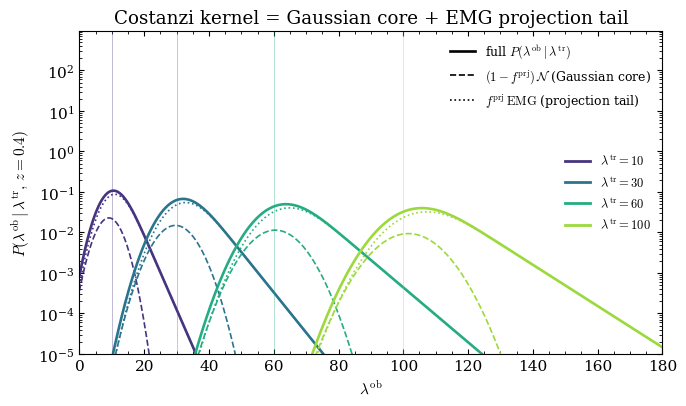

In [2]:
from richness_selection.plob_ltr import (
    mu_model, sig_model, tau_model, fprj_model,
)


def _gauss_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


def _P_parts(lob, ltr, z):
    """Return (gauss_only, emg_tail, full) at lob values.

    gauss_only = (1 - f_prj) * N(lob; mu, sigma)             -- pure noise / background
    emg_tail   = f_prj       * EMG_pdf(lob; mu, sigma, tau)  -- projection boost
    full       = gauss_only + emg_tail                       -- what P_lob_given_ltr returns
    """
    mu    = mu_model(ltr, z)
    sigma = sig_model(ltr, z)
    tau   = tau_model(ltr, z)
    fprj  = min(1.0, fprj_model(ltr, z))
    lob   = np.asarray(lob, dtype=float)

    from scipy.special import erfc
    gauss_only = (1.0 - fprj) * _gauss_pdf(lob, mu, sigma)
    exp_arg    = 0.5 * tau * (2.0 * mu + tau * sigma ** 2 - 2.0 * lob)
    erfc_arg   = (mu + tau * sigma ** 2 - lob) / (np.sqrt(2.0) * sigma)
    emg_tail   = fprj * 0.5 * tau * np.exp(exp_arg) * erfc(erfc_arg)
    return gauss_only, emg_tail, gauss_only + emg_tail


z = 0.4
ltrs = [10., 30., 60., 100.]
colours = viridis(np.linspace(0.15, 0.85, len(ltrs)))

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for lt, c in zip(ltrs, colours):
    lob = np.linspace(max(0., lt - 6. * np.sqrt(lt)), lt + 6. * np.sqrt(lt) + 40., 400)
    gauss, emg, full = _P_parts(lob, lt, z)
    # Gaussian core: dashed; EMG projection tail: dotted; full: solid.
    ax.plot(lob, full,  color=c, lw=1.9, ls='-')
    ax.plot(lob, gauss, color=c, lw=1.2, ls='--')
    ax.plot(lob, emg,   color=c, lw=1.2, ls=':')
    ax.axvline(lt, color=c, lw=0.6, alpha=0.4)

# Two legends: line-style keys (top), colour keys for ltr (below).
style_handles = [
    plt.Line2D([], [], color='k', lw=1.9, ls='-',
               label=r'full $P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr})$'),
    plt.Line2D([], [], color='k', lw=1.2, ls='--',
               label=r'$(1-f^{\rm prj})\,\mathcal{N}$ (Gaussian core)'),
    plt.Line2D([], [], color='k', lw=1.2, ls=':',
               label=r'$f^{\rm prj}\,\mathrm{EMG}$ (projection tail)'),
]
first_legend = ax.legend(handles=style_handles, loc='upper right', frameon=False)
ax.add_artist(first_legend)
ax.legend(
    [plt.Line2D([], [], color=c, lw=2.0) for c in colours],
    [fr'$\lambda^{{\rm tr}}={lt:g}$' for lt in ltrs],
    loc='center right', frameon=False,
)

ax.set_yscale('log')
ax.set_xlabel(r'$\lambda^{\rm ob}$')
ax.set_ylabel(r'$P(\lambda^{\rm ob}\,|\,\lambda^{\rm tr},\,z=0.4)$')
ax.set_xlim(0, 180)
ax.set_ylim(1e-5, None)
ax.set_title('Costanzi kernel = Gaussian core + EMG projection tail')
plt.tight_layout()
plt.show()

## 2. $S_i(M)$ per richness bin

$S_i(M, z)=\int\!d\lambda^{\rm tr}\,\mathcal K_i(\lambda^{\rm tr},z)\,P(\lambda^{\rm tr}\,|\,M,z)$ collapses the $\lambda^{\rm ob}$ integral analytically (via the EMG CDF) and leaves a single 1-D Gauss–Legendre quadrature over $\lambda^{\rm tr}$. The plot below shows $S_i(M)$ for the Y3 richness bins at fixed $z=0.4$, for both the HOD and log-normal MORs.

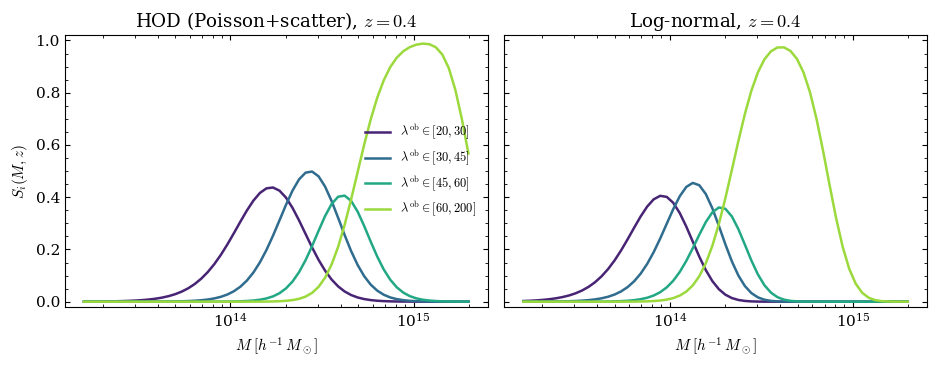

CPU times: user 1.11 s, sys: 19.8 ms, total: 1.13 s
Wall time: 886 ms


In [3]:
%%time
z_plot = 0.4
Mgrid = np.logspace(13.2, 15.3, 60)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)

labels = [fr'$\lambda^{{\rm ob}}\in[{lo:g},{hi:g}]$' for lo, hi in Y3_LAM_BINS]
palette = viridis(np.linspace(0.1, 0.85, len(Y3_LAM_BINS)))

for ax, mor, name in [(axes[0], hod,  'HOD (Poisson+scatter)'),
                       (axes[1], logn, 'Log-normal')]:
    for (lo, hi), c, lab in zip(Y3_LAM_BINS, palette, labels):
        Si = S_i(Mgrid, z_plot, lo, hi, mor, N_q=64)
        ax.semilogx(Mgrid, Si, color=c, lw=1.8, label=lab)
    ax.set_xlabel(r'$M\;[h^{-1}\,M_\odot]$')
    ax.set_title(fr'{name}, $z={z_plot}$')
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel(r'$S_i(M,z)$')
axes[0].legend(loc='center right')
plt.tight_layout(); plt.show()

### 2b. $S_i(M, z)$ heat-map per bin

$S_i$ varies modestly with $z$ through the Costanzi splines and through the MOR's $\epsilon$ parameter. The $(M, z)$ heat-map shows where each bin selects.

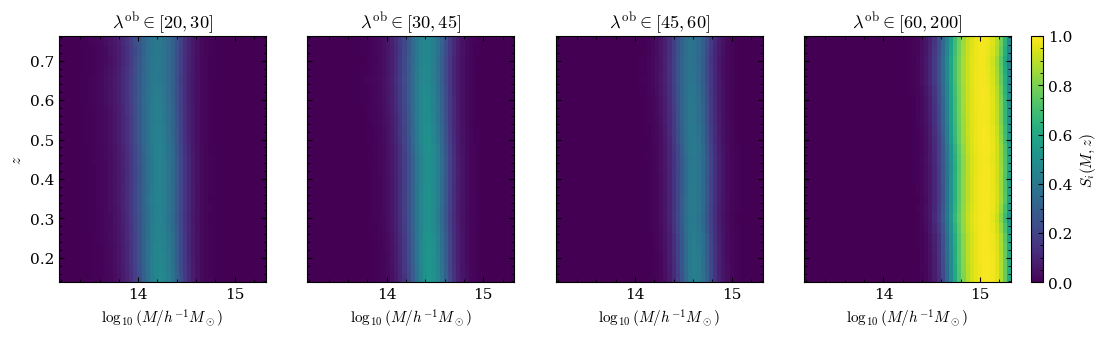

CPU times: user 1.79 s, sys: 76.8 ms, total: 1.87 s
Wall time: 1.91 s


In [4]:
%%time
Mgrid = np.logspace(13.2, 15.3, 50)
zgrid = np.linspace(0.15, 0.75, 25)

fig, axes = plt.subplots(1, len(Y3_LAM_BINS),
                          figsize=(3.2 * len(Y3_LAM_BINS), 3.2),
                          sharey=True)
for ax, (lo, hi) in zip(axes, Y3_LAM_BINS):
    grid = np.zeros((zgrid.size, Mgrid.size))
    for iz, z in enumerate(zgrid):
        grid[iz] = S_i(Mgrid, float(z), lo, hi, hod, N_q=48)
    pc = ax.pcolormesh(np.log10(Mgrid), zgrid, grid,
                       cmap='viridis', vmin=0., vmax=1., shading='auto')
    ax.set_xlabel(r'$\log_{10}(M/h^{-1}M_\odot)$')
    ax.set_title(fr'$\lambda^{{\rm ob}}\in[{lo:g},{hi:g}]$')
axes[0].set_ylabel('$z$')
fig.colorbar(pc, ax=axes.ravel().tolist(),
              fraction=0.02, pad=0.02, label=r'$S_i(M,z)$')
plt.show()

### 2d. Above-threshold selection $S(M\,|\,\lambda^{\rm ob}>\lambda_{\min})$

The complementary CDF at a single richness cut is the probability that a halo of mass $M$ at redshift $z$ is observed above $\lambda_{\min}$, irrespective of how far above. This is the quantity that defines the \textsc{redMaPPer} catalogue itself; for the cosmology pipeline, $S_i$ with a finite upper edge picks out a bin within that catalogue.

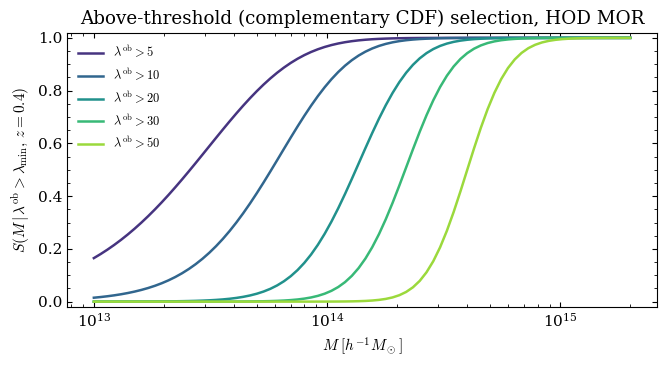

In [5]:
lam_mins = [5., 10., 20., 30., 50.]
Mgrid   = np.logspace(13.0, 15.3, 80)
z_plot  = 0.4
cmap_th = viridis(np.linspace(0.15, 0.85, len(lam_mins)))

fig, ax = plt.subplots(figsize=(6.8, 3.8))
for lmin, c in zip(lam_mins, cmap_th):
    Sth = S_threshold(Mgrid, z_plot, lmin, hod, N_q=48)
    ax.semilogx(Mgrid, Sth, color=c, lw=1.8,
                 label=fr'$\lambda^{{\rm ob}}>{lmin:g}$')
ax.set_xlabel(r'$M\;[h^{-1}M_\odot]$')
ax.set_ylabel(r'$S(M\,|\,\lambda^{\rm ob}>\lambda_{\min},\,z=0.4)$')
ax.set_title(r'Above-threshold (complementary CDF) selection, HOD MOR')
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.tight_layout(); plt.show()

## 3. Sensitivity of $S_i(M)$ to the HOD scaling relation

The HOD mean-satellite relation is
$$\langle\lambda^{\rm sat}\rangle(M, z) = \left(\frac{M - M_{\rm min}}{M_1 - M_{\rm min}}\right)^\alpha \left(\frac{1+z}{1+z_\star}\right)^\epsilon\,.$$
Varying the amplitude $M_1$ slides the $M$-axis; varying the slope $\alpha$ tilts the rise.

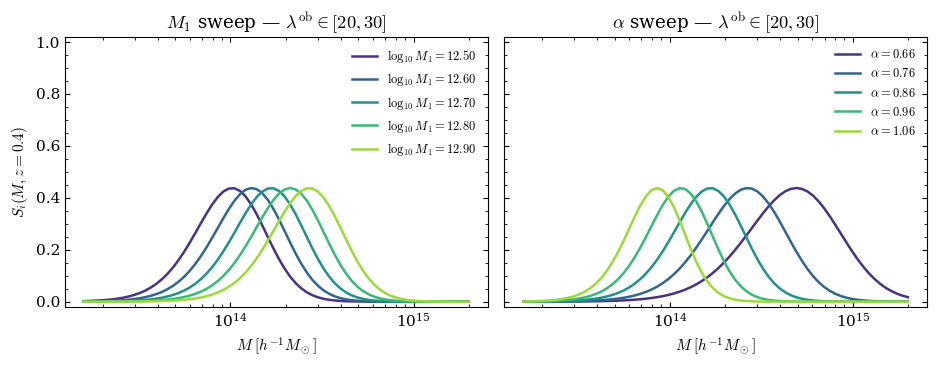

In [6]:
z_plot = 0.4
lam_min, lam_max = 20., 30.         # one representative bin
Mgrid = np.logspace(13.2, 15.3, 70)

# --- M1 sweep ---
log10_M1_default = np.log10(hod.M1)
log10_M1_values = log10_M1_default + np.array([-0.20, -0.10, 0.0, +0.10, +0.20])

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
cmap_M1 = viridis(np.linspace(0.15, 0.85, len(log10_M1_values)))
for val, c in zip(log10_M1_values, cmap_M1):
    mor_v = MOR(log10_M1=val)
    Si = S_i(Mgrid, z_plot, lam_min, lam_max, mor_v, N_q=48)
    axes[0].semilogx(Mgrid, Si, color=c, lw=1.8,
                      label=fr'$\log_{{10}}M_1={val:.2f}$')
axes[0].set_xlabel(r'$M\;[h^{-1}M_\odot]$')
axes[0].set_ylabel(r'$S_i(M,z=0.4)$')
axes[0].set_title(fr'$M_1$ sweep — $\lambda^{{\rm ob}}\in[{lam_min:g},{lam_max:g}]$')
axes[0].legend()

# --- alpha sweep ---
alpha_default = hod.alpha
alpha_values = alpha_default + np.array([-0.20, -0.10, 0.0, +0.10, +0.20])
cmap_a = viridis(np.linspace(0.15, 0.85, len(alpha_values)))
for val, c in zip(alpha_values, cmap_a):
    mor_v = MOR(alpha=val)
    Si = S_i(Mgrid, z_plot, lam_min, lam_max, mor_v, N_q=48)
    axes[1].semilogx(Mgrid, Si, color=c, lw=1.8,
                      label=fr'$\alpha={val:.2f}$')
axes[1].set_xlabel(r'$M\;[h^{-1}M_\odot]$')
axes[1].set_title(fr'$\alpha$ sweep — $\lambda^{{\rm ob}}\in[{lam_min:g},{lam_max:g}]$')
axes[1].legend()

for ax in axes:
    ax.set_ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()

## 4. Joint $S_{ij}(M, z)$ and number counts $N_{ij}$

$N_{ij}$ is the expected number of clusters in a joint $(\lambda^{\rm ob}, z^{\rm ob})$ bin,

$$N_{ij} \;=\; \int\!dM\!\int\!dz^{\rm tr}\; \Omega(z^{\rm tr})\,\frac{dV}{d\Omega\,dz^{\rm tr}}\, n(M,z^{\rm tr})\, S_i(M,z^{\rm tr})\,\mathcal K_j(z^{\rm tr}).$$

Three $z^{\rm tr}$-dependent factors compete: the comoving volume element $dV/(dz\,d\Omega)$ (grows), the halo mass function $n(M, z^{\rm tr})$ (shrinks), and the effective survey solid angle $\Omega(z^{\rm tr})$ (cuts off at high $z$ because redMaPPer's red-sequence photometry loses contrast).

### 4a. Survey Omega(z): SDSS vs DES

We port the polynomial fits used in the `y3_cluster_cpp` pipeline:
`omega_z_sdss(z)` (Costanzi 2019b / 2021; plateau $\sim\!10{,}260\,\mathrm{deg}^2$ in $z\in[0.1, 0.4]$) and
`omega_z_des(z)` (DES Y1 volume-limited; plateau $\sim\!1500\,\mathrm{deg}^2$ below $z\!\sim\!0.5$ with a steep rolloff by $z\!\sim\!0.7$).

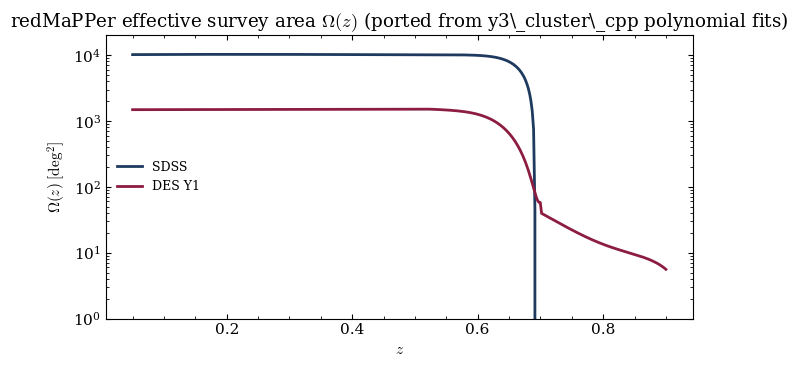

In [7]:
zgrid = np.linspace(0.05, 0.90, 400)
omega_sdss = omega_z_sdss(zgrid) / DEG2_TO_STER
omega_des  = omega_z_des(zgrid)  / DEG2_TO_STER

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(zgrid, omega_sdss, color=NAVY,    lw=2.0, label='SDSS')
ax.plot(zgrid, omega_des,  color=CRIMSON, lw=2.0, label='DES Y1')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$\Omega(z)\;[\mathrm{deg}^2]$')
ax.set_title(r'redMaPPer effective survey area $\Omega(z)$ ' +
             r'(ported from y3\_cluster\_cpp polynomial fits)')
ax.set_yscale('log')
ax.set_ylim(1e0, 2e4)
ax.legend(loc='center left')
plt.tight_layout(); plt.show()

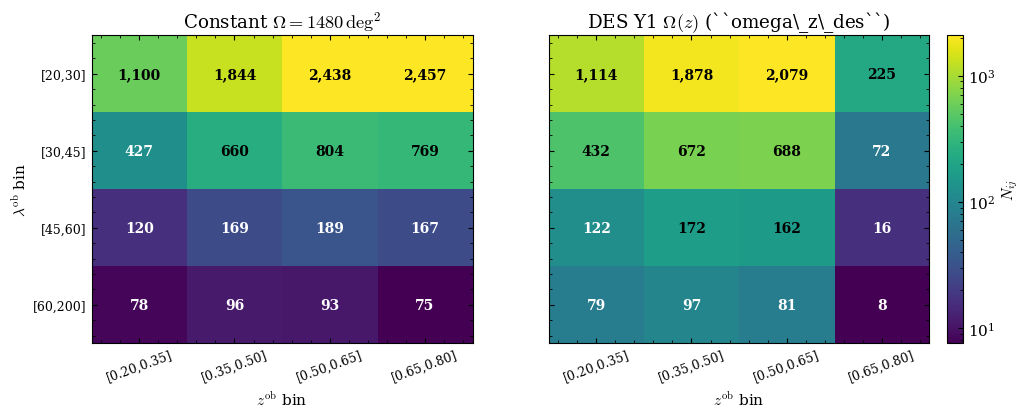


Total N across bins:  constant Omega = 11,485;  DES Omega(z) = 7,897
CPU times: user 894 ms, sys: 39.7 ms, total: 934 ms
Wall time: 944 ms


In [8]:
%%time
from matplotlib.colors import LogNorm

# DES-Y1-like bin grid.  Include a z > 0.65 bin to show the Omega(z) rolloff.
Y3_Z_BINS     = [(0.20, 0.35), (0.35, 0.50), (0.50, 0.65), (0.65, 0.80)]
Y3_LAM_MATRIX = [(20., 30.), (30., 45.), (45., 60.), (60., 200.)]
SIGMA_Z       = 0.02

# Use the DES Y1 polynomial Omega(z) ported from omega_z_des.hh
def _matrix(solid_angle):
    N = np.zeros((len(Y3_LAM_MATRIX), len(Y3_Z_BINS)))
    for i, (lo, hi) in enumerate(Y3_LAM_MATRIX):
        for j, bz in enumerate(Y3_Z_BINS):
            N[i, j] = N_ij(bin_lam=(lo, hi), bin_z=bz,
                           cosmo=cosmo, hmf=hmf, mor=hod, sigma_z=SIGMA_Z,
                           N_M=40, N_z=28, N_q=32,
                           solid_angle=solid_angle)
    return N

# Constant baseline at the DES Y1 plateau (~1500 deg^2) for comparison.
plateau_ster = DES_AREA_DEG2 * DEG2_TO_STER
N_const = _matrix(lambda z: omega_z_const(z, plateau_ster))
N_des   = _matrix(omega_z_des)


def _plot_matrix(ax, N, title):
    im = ax.imshow(
        N, cmap='viridis',
        norm=LogNorm(vmin=max(1., N.min()), vmax=N.max()),
        aspect='auto',
    )
    log_mid = np.sqrt(N.min() * N.max()) if N.min() > 0 else N.max() * 0.3
    for i in range(N.shape[0]):
        for j in range(N.shape[1]):
            val = N[i, j]
            colour = 'white' if val < log_mid else 'black'
            ax.text(j, i, f'{int(round(val)):,}',
                    ha='center', va='center', color=colour,
                    fontsize=10, fontweight='bold')
    ax.set_xticks(np.arange(len(Y3_Z_BINS)))
    ax.set_xticklabels([f'[{lo:.2f},{hi:.2f}]' for lo, hi in Y3_Z_BINS],
                        rotation=20, fontsize=9)
    ax.set_yticks(np.arange(len(Y3_LAM_MATRIX)))
    ax.set_yticklabels([fr'[{lo:g},{hi:g}]' for lo, hi in Y3_LAM_MATRIX],
                        fontsize=9)
    ax.set_xlabel(r'$z^{\rm ob}$ bin')
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
im1 = _plot_matrix(axes[0], N_const,
                    fr'Constant $\Omega = {DES_AREA_DEG2:g}\,\mathrm{{deg}}^2$')
im2 = _plot_matrix(axes[1], N_des,
                    r'DES Y1 $\Omega(z)$ (``omega\_z\_des``)')
axes[0].set_ylabel(r'$\lambda^{\rm ob}$ bin')
fig.colorbar(im2, ax=axes, label=r'$N_{ij}$', fraction=0.04, pad=0.02)
plt.show()

print()
print(f'Total N across bins:  constant Omega = {N_const.sum():,.0f};  '
      f'DES Omega(z) = {N_des.sum():,.0f}')

## 5. Timing

Per-call cost of each building block, and scaling of `N_ij` with $(N_M, N_z, N_q)$. `K_i` is vectorised over $\lambda^{\rm tr}$; `S_i` does a Python loop over $M$; `N_ij` does a Python loop over $z$ and calls `S_i(M_grid, z)` inside. So $N_{ij}$ cost scales as $N_z$ (outer) $\times N_M$ (inner loop inside `S_i`) and only weakly on $N_q$.

In [9]:
import time


def _best(fn, reps):
    b = float('inf')
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); b = min(b, time.perf_counter() - t0)
    return b


# Per-call
lams = np.linspace(10., 80., 32)
Ms_bench = np.logspace(13.2, 15.3, 40)
print(f"{'kernel':>22s}  {'time':>10s}")
print(f"{'K_i (32 ltr nodes)':>22s}  {_best(lambda: K_i(lams, 0.4, 20., 30.), 50) * 1e3:>8.3f} ms")
print(f"{'S_i scalar, N_q=32':>22s}  {_best(lambda: S_i(1e14, 0.4, 20., 30., hod, N_q=32), 20) * 1e3:>8.3f} ms")
print(f"{'S_i over 40 M':>22s}  {_best(lambda: S_i(Ms_bench, 0.4, 20., 30., hod, N_q=32), 10) * 1e3:>8.2f} ms")

# N_ij scaling
print('\nN_ij scaling')
print(f"{'preset':>8s}  {'N_M':>4} {'N_z':>4} {'N_q':>4}  {'per cell':>10s}  {'4x3 matrix':>12s}")
for name, NM, Nz, Nq in [('tiny', 20, 12, 16),
                         ('default', 32, 24, 32),
                         ('Y3', 40, 28, 32)]:
    b = _best(lambda NM=NM, Nz=Nz, Nq=Nq:
              N_ij(bin_lam=(20., 30.), bin_z=(0.3, 0.5),
                   cosmo=cosmo, hmf=hmf, mor=hod, sigma_z=0.02,
                   N_M=NM, N_z=Nz, N_q=Nq), 3)
    print(f"{name:>8s}  {NM:>4d} {Nz:>4d} {Nq:>4d}  {b * 1e3:>7.0f} ms  {b * 12:>10.2f} s")

                kernel        time
    K_i (32 ltr nodes)     0.129 ms
    S_i scalar, N_q=32     0.196 ms
         S_i over 40 M      7.56 ms

N_ij scaling
  preset   N_M  N_z  N_q    per cell    4x3 matrix
    tiny    20   12   16        4 ms        0.05 s
 default    32   24   32        9 ms        0.11 s
      Y3    40   28   32       11 ms        0.13 s
